In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("C:/Users/Earl/Downloads/KaggleV2-May-2016.csv/KaggleV2-May-2016.csv")
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [5]:
df.shape

(110527, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [7]:
df.isnull().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

In [8]:
df['No-show'].value_counts()

No     88208
Yes    22319
Name: No-show, dtype: int64

In [9]:
df.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [10]:
attendance = df['No-show'].value_counts(normalize=True) * 100
attendance

No     79.806744
Yes    20.193256
Name: No-show, dtype: float64

In [11]:
df[df['Age'] < 0]

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
99832,4.659432e+14,5775010,F,2016-06-06T08:58:13Z,2016-06-06T00:00:00Z,-1,ROMÃO,0,0,0,0,0,0,No


In [12]:
len(df[df['Age'] < 0])

1

In [13]:
df.duplicated().sum()

0

In [14]:
df['Gender'].value_counts()

F    71840
M    38687
Name: Gender, dtype: int64

In [15]:
df['SMS_received'].value_counts()

0    75045
1    35482
Name: SMS_received, dtype: int64

In [16]:
df['Scholarship'].value_counts()

0    99666
1    10861
Name: Scholarship, dtype: int64

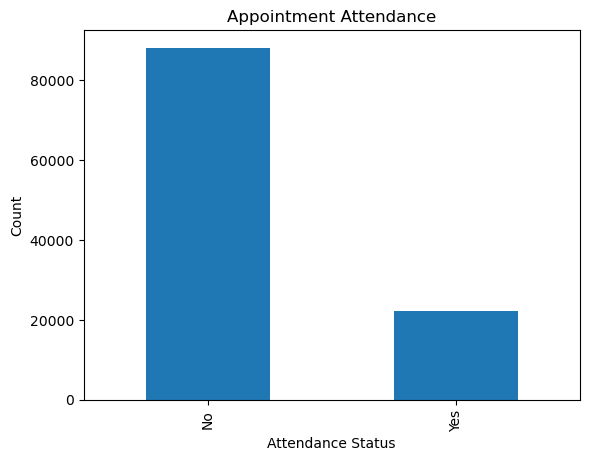

In [19]:
import matplotlib.pyplot as plt

df['No-show'].value_counts().plot(kind='bar')

plt.title('Appointment Attendance')
plt.xlabel('Attendance Status')
plt.ylabel('Count')

plt.show()

# Data Cleaning

Removing invalid age values and preparing the dataset for analysis

In [21]:
df_clean = df[df['Age'] >= 0].copy()

print(df_clean.shape)

(110526, 14)


In [47]:
df_clean['ScheduledDay'] = pd.to_datetime(df_clean['ScheduledDay'])
df_clean['AppointmentDay'] = pd.to_datetime(df_clean['AppointmentDay'])

df_clean[['ScheduledDay', 'AppointmentDay']].head()

,ScheduledDay,AppointmentDay
0,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00
1,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00
2,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00
3,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00
4,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00


In [24]:
df_clean['WaitDays'] = (
    df_clean['AppointmentDay'].dt.date -
    df_clean['ScheduledDay'].dt.date
).dt.days

In [26]:
df_clean[['ScheduledDay', 'AppointmentDay', 'WaitDays']].head()

,ScheduledDay,AppointmentDay,WaitDays
0,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,0
1,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,0
2,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,0
3,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,0
4,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,0


In [27]:
df_clean['WaitDays'].describe()

count    110526.000000
mean         10.183794
std          15.255034
min          -6.000000
25%           0.000000
50%           4.000000
75%          15.000000
max         179.000000
Name: WaitDays, dtype: float64

In [28]:
sms_analysis = pd.crosstab(
    df_clean['SMS_received'],
    df_clean['No-show'],
    normalize='index' 
) * 100

sms_analysis

No-show,No,Yes
SMS_received,,
0,83.296466,16.703534
1,72.425455,27.574545


In [29]:
gender_analysis = pd.crosstab(
    df_clean['Gender'],
    df_clean['No-show'],
    normalize='index'
) * 100

gender_analysis

No-show,No,Yes
Gender,,
F,79.685129,20.314871
M,80.032052,19.967948


In [30]:
df_clean['AgeGroup'] = pd.cut(
    df_clean['Age'],
    bins=[0,18,40,65,120],
    labels=['0-18', '19-40', '41-65', '66+']
)

In [31]:
age_analysis = pd.crosstab(
    df_clean['AgeGroup'],
    df_clean['No-show'],
    normalize='index'
) * 100

age_analysis

No-show,No,Yes
AgeGroup,,
0-18,77.462787,22.537213
19-40,76.820568,23.179432
41-65,82.127415,17.872585
66+,84.467333,15.532667


In [32]:
df_clean[df_clean['WaitDays'] < 0]

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,WaitDays,AgeGroup
27033,7.839273e+12,5679978,M,2016-05-10 10:51:53+00:00,2016-05-09 00:00:00+00:00,38,RESISTÊNCIA,0,0,0,0,1,0,Yes,-1,19-40
55226,7.896294e+12,5715660,F,2016-05-18 14:50:41+00:00,2016-05-17 00:00:00+00:00,19,SANTO ANTÔNIO,0,0,0,0,1,0,Yes,-1,19-40
64175,2.425226e+13,5664962,F,2016-05-05 13:43:58+00:00,2016-05-04 00:00:00+00:00,22,CONSOLAÇÃO,0,0,0,0,0,0,Yes,-1,19-40
71533,9.982316e+14,5686628,F,2016-05-11 13:49:20+00:00,2016-05-05 00:00:00+00:00,81,SANTO ANTÔNIO,0,0,0,0,0,0,Yes,-6,66+
72362,3.787482e+12,5655637,M,2016-05-04 06:50:57+00:00,2016-05-03 00:00:00+00:00,7,TABUAZEIRO,0,0,0,0,0,0,Yes,-1,0-18


In [33]:
len(df_clean[df_clean['WaitDays'] < 0])

5

In [37]:
df_clean = df_clean[df_clean['WaitDays'] >= 0].copy()

df_clean['WaitGroup'] = pd.cut(
    df_clean['WaitDays'],
    bins=[0,7,30,180],
    labels=['0-7 Days', '8-30 Days', '31+ Days']
)

In [38]:
wait_analysis = pd.crosstab(
    df_clean['WaitGroup'],
    df_clean['No-show'],
    normalize='index'
) * 100

wait_analysis

No-show,No,Yes
WaitGroup,,
0-7 Days,75.852105,24.147895
8-30 Days,68.277997,31.722003
31+ Days,66.997495,33.002505


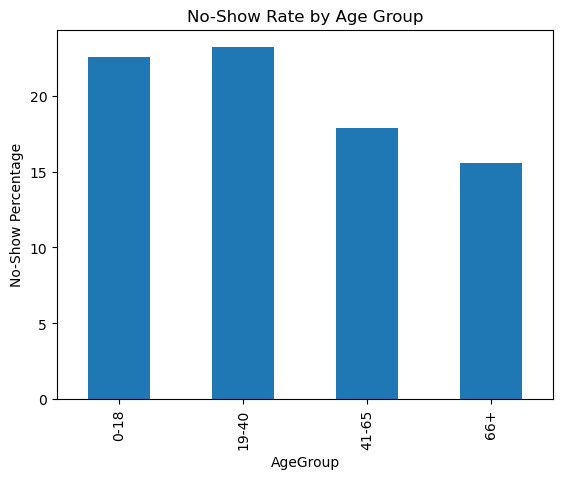

In [39]:
age_analysis['Yes'].plot(kind='bar')

plt.title('No-Show Rate by Age Group')
plt.ylabel('No-Show Percentage')
plt.show()

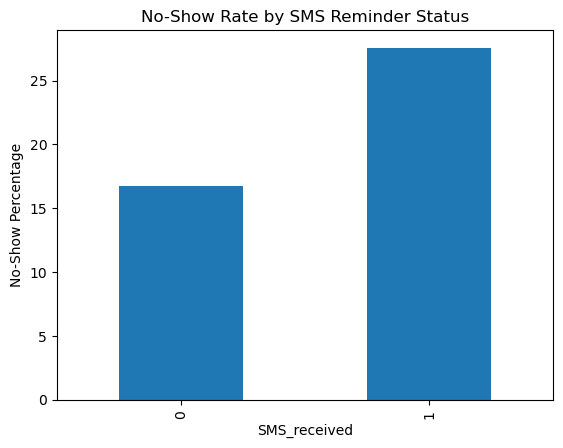

In [40]:
sms_analysis['Yes'].plot(kind='bar')

plt.title('No-Show Rate by SMS Reminder Status')
plt.ylabel('No-Show Percentage')
plt.show()

In [41]:
len(df_clean[df_clean['WaitDays'] < 0])

0

In [42]:
wait_analysis

No-show,No,Yes
WaitGroup,,
0-7 Days,75.852105,24.147895
8-30 Days,68.277997,31.722003
31+ Days,66.997495,33.002505


In [43]:
wait_analysis = pd.crosstab(
    df_clean['WaitGroup'],
    df_clean['No-show'],
    normalize='index'
) * 100

wait_analysis

No-show,No,Yes
WaitGroup,,
0-7 Days,75.852105,24.147895
8-30 Days,68.277997,31.722003
31+ Days,66.997495,33.002505


In [44]:
diabetes_analysis = pd.crosstab(
    df_clean['Diabetes'],
    df_clean['No-show'],
    normalize='index'
) * 100

diabetes_analysis

No-show,No,Yes
Diabetes,,
0,79.640859,20.359141
1,81.996727,18.003273


In [45]:
hypertension_analysis = pd.crosstab(
    df_clean['Hipertension'],
    df_clean['No-show'],
    normalize='index'
) * 100

hypertension_analysis

No-show,No,Yes
Hipertension,,
0,79.100541,20.899459
1,82.698041,17.301959


In [46]:
scholarship_analysis = pd.crosstab(
    df_clean['Scholarship'],
    df_clean['No-show'],
    normalize='index'
) * 100

scholarship_analysis

No-show,No,Yes
Scholarship,,
0,80.196669,19.803331
1,76.263696,23.736304


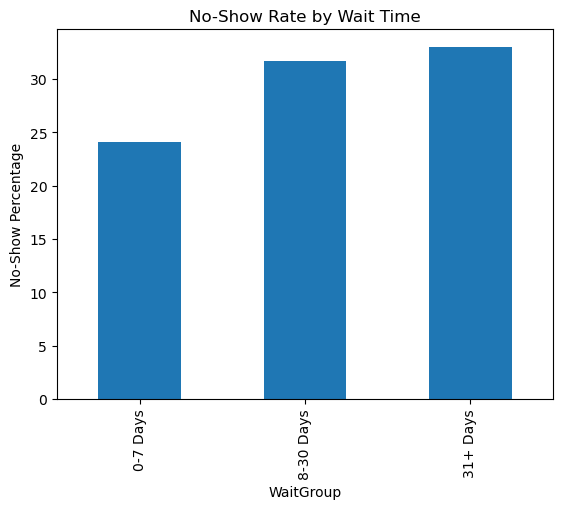

In [48]:
wait_analysis['Yes'].plot(kind='bar')

plt.title('No-Show Rate by Wait Time')
plt.ylabel('No-Show Percentage')
plt.show()

In [49]:
df_clean.to_csv(
    'C:/Users/Earl/Documents/Github/Healthcare-Noshow-Capstone/data/appointments_cleaned.csv',
    index=False
)

In [50]:
df_clean.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,WaitDays,AgeGroup,WaitGroups,WaitGroup
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,0,1,0,0,0,0,No,0,41-65,NaN,NaN
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,0,0,0,0,0,No,0,41-65,NaN,NaN
2,4.262962e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,0,0,0,0,0,0,No,0,41-65,NaN,NaN
3,8.679512e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No,0,0-18,NaN,NaN
4,8.841186e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,0,1,1,0,0,0,No,0,41-65,NaN,NaN


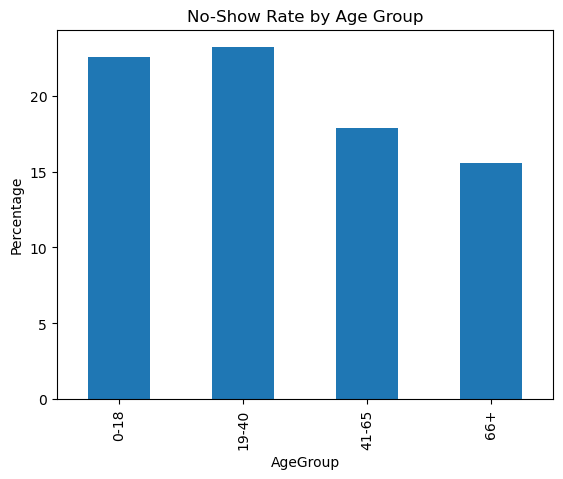

In [51]:
age_analysis['Yes'].plot(kind='bar')
plt.title('No-Show Rate by Age Group')
plt.ylabel('Percentage')
plt.show()

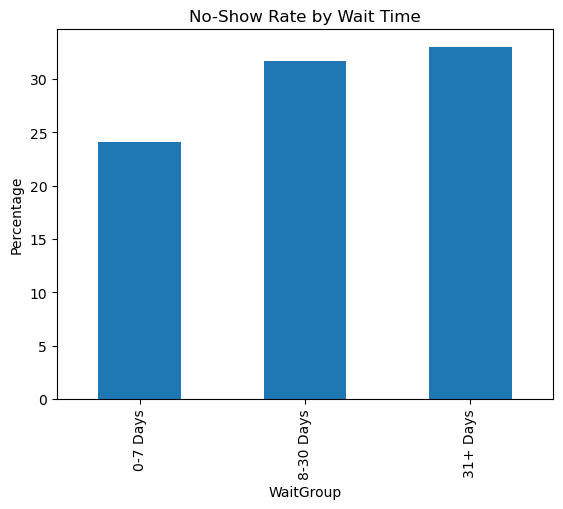

In [52]:
wait_analysis['Yes'].plot(kind='bar')
plt.title('No-Show Rate by Wait Time')
plt.ylabel('Percentage')
plt.show()

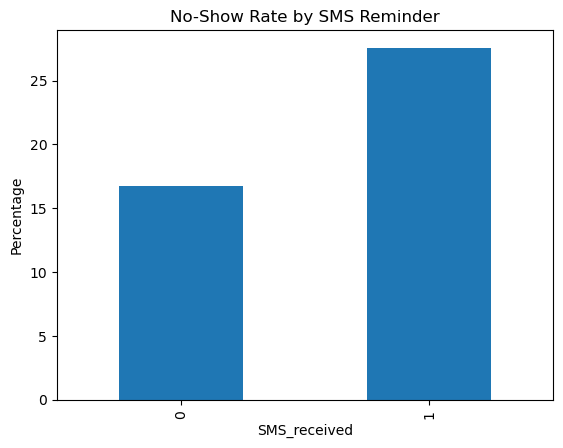

In [53]:
sms_analysis['Yes'].plot(kind='bar')
plt.title('No-Show Rate by SMS Reminder')
plt.ylabel('Percentage')
plt.show()

# Statistical Analysis

In [54]:
from scipy.stats import chi2_contingency

In [55]:
sms_table = pd.crosstab(
    df_clean['SMS_received'],
    df_clean['No-show']
)

print(sms_table)

chi2, p, dof, expected = chi2_contingency(sms_table)

print(f"Chi-Squared Statistics: {chi2}")
print(f"P-Value: {p}")

No-show          No    Yes
SMS_received              
0             62509  12530
1             25698   9784
Chi-Squared Statistics: 1767.9781891546713
P-Value: 0.0


In [56]:
gender_table = pd.crosstab(
    df_clean['Gender'],
    df_clean['No-show']
)

print(gender_table)

chi2, p, dof, expected = chi2_contingency(gender_table)

print(f"Chi-Squared Statistics: {chi2}")
print(f"p-Value {p}")

No-show     No    Yes
Gender               
F        57245  14591
M        30962   7723
Chi-Squared Statistics: 1.8653434872450756
p-Value 0.172009349904053


In [57]:
scholarship_table = pd.crosstab(
    df_clean['Scholarship'],
    df_clean['No-show']
)

print(scholarship_table)

chi2, p, dof, expected = chi2_contingency(scholarship_table)

print(f"Chi-Squared Statistics: {chi2}")
print(f"P-Value: {p}")

No-show         No    Yes
Scholarship              
0            79924  19736
1             8283   2578
Chi-Squared Statistics: 93.77103096576741
P-Value: 3.542183519972575e-22
